# Univariate analysis
We analyse each single columns

In [1]:
# Do the necessary import
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
pickle_file = "HR_analytics_data_clean.pkl"

In [2]:
# Lets verify that above works
df = pd.read_pickle(pickle_file)
print(df.info(memory_usage='deep'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int8    
 1   Attrition                 1470 non-null   bool    
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int16   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int8    
 6   Education                 1470 non-null   int8    
 7   EducationField            1470 non-null   category
 8   EnvironmentSatisfaction   1470 non-null   int8    
 9   Gender                    1470 non-null   category
 10  HourlyRate                1470 non-null   int8    
 11  JobInvolvement            1470 non-null   int8    
 12  JobLevel                  1470 non-null   int8    
 13  JobRole                   1470 non-null   catego

# Univariate Analysis
- Means single variable analysis. 

## A) For Numerical Columns:

### Histogram: Age, etc

In [3]:
# identify numeric columns
numeric_df = df.select_dtypes(include=['number'])

print("numeric_df:\n",numeric_df.head(5))
print("\n\nnumeric columns:",numeric_df.columns)

numeric_df:
    Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   41       1102                 1          2                        2   
1   49        279                 8          1                        3   
2   37       1373                 2          2                        4   
3   33       1392                 3          4                        4   
4   27        591                 2          1                        1   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          94               3         2                4           5993  ...   
1          61               2         2                2           5130  ...   
2          92               2         1                3           2090  ...   
3          56               3         1                3           2909  ...   
4          40               3         1                2           3468  ...   

   PerformanceRating  RelationshipSatisfaction  StockOp

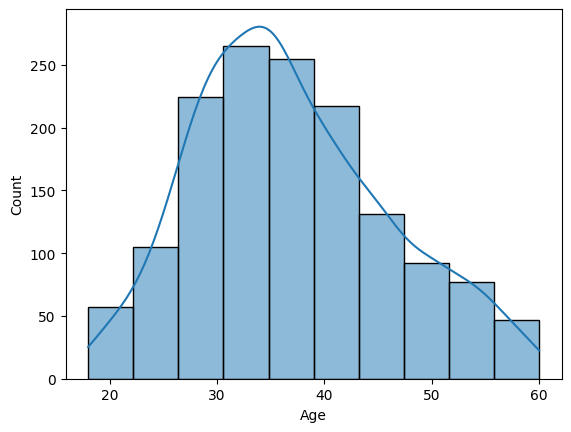

In [4]:
# step0: Plot histogram for 1 column: Age 

col = "Age"
sns.histplot(df[col], bins=10, kde=True) # kde--> Kernel Density Estimation 
plt.show()

# Now lets prettify above

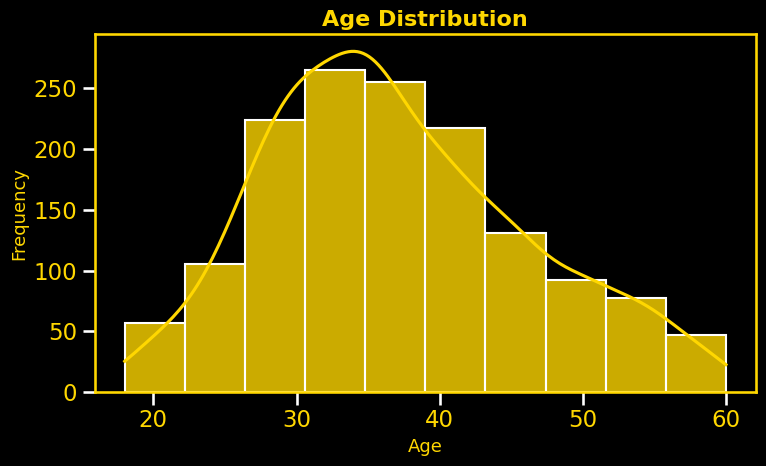

In [5]:
# step1: Prettify above. Plot histogram for 1 column: Age 

col = "Age"

plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

plt.figure(figsize=(8,5))

sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8, )

# Titles and labels
plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
plt.xlabel(col, fontsize=13, color='gold')
plt.ylabel("Frequency", fontsize=13, color='gold')

# Customize ticks and spines
plt.xticks(color='gold')
plt.yticks(color='gold')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('gold')

# Show plot
plt.tight_layout()
plt.show()

# Obser: Most of employees are in age range of 26 to 40

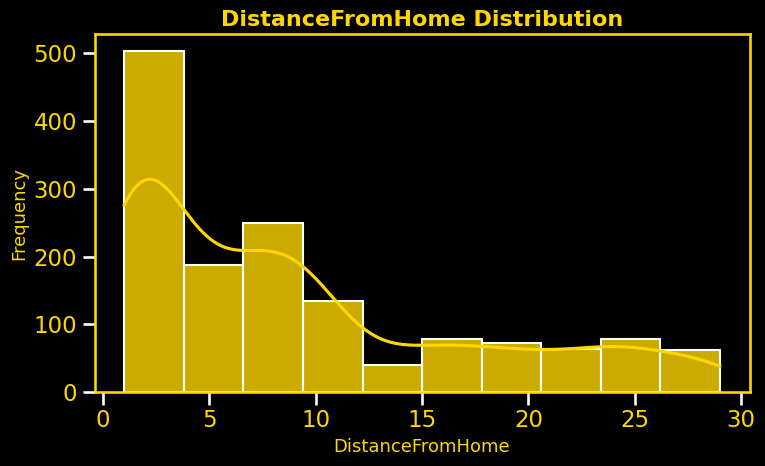

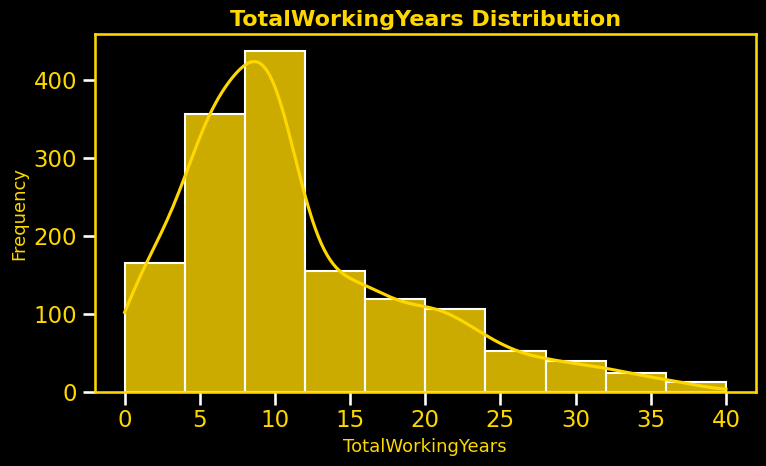

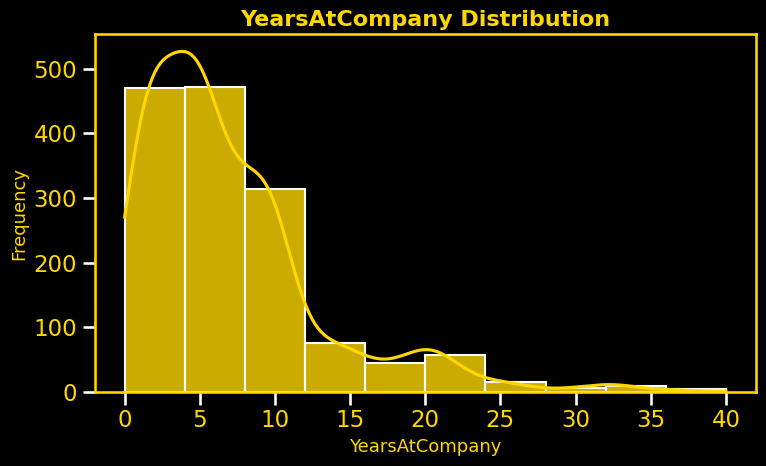

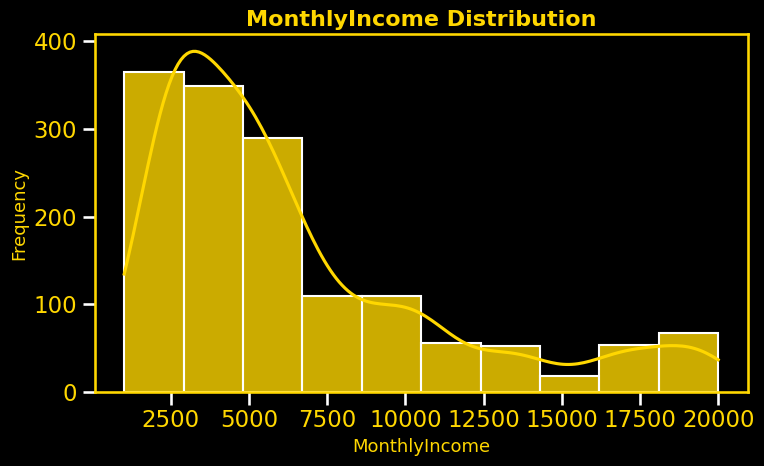

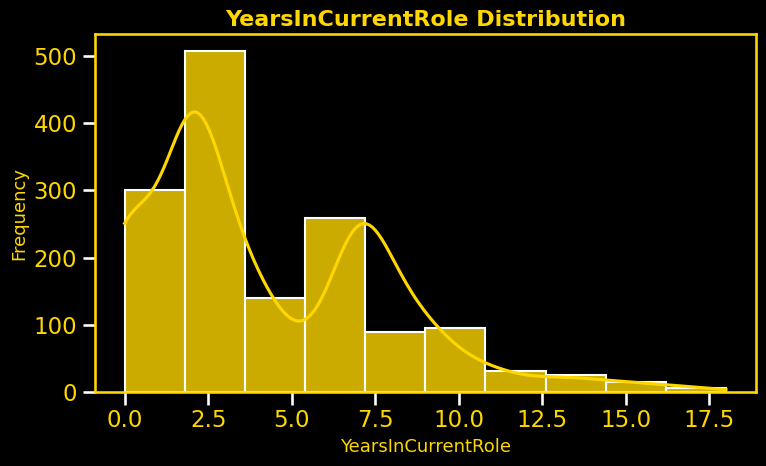

In [6]:
# step2: Now do this for few more columns: "DistanceFromHome", "TotalWorkingYears", 
# "YearsAtCompany", "MonthlyIncome", "YearsInCurrentRole"

columns = ["DistanceFromHome", "TotalWorkingYears", "YearsAtCompany", 
           "MonthlyIncome", "YearsInCurrentRole"
]

for col in columns:
    
    plt.style.use("dark_background")  
    
    # Optional: control Seaborn palette and font scale
    sns.set_palette(["gold"])
    sns.set_context("talk")
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], bins=10, kde=True, color='gold', edgecolor='white', alpha=0.8)
    
    # Titles and labels
    plt.title(f"{col} Distribution", fontsize=16, color='gold', fontweight='bold')
    plt.xlabel(col, fontsize=13, color='gold')
    plt.ylabel("Frequency", fontsize=13, color='gold')
    
    # Customize ticks and spines
    plt.xticks(color='gold')
    plt.yticks(color='gold')
    for spine in plt.gca().spines.values():
        spine.set_edgecolor('gold')
    
    # Show plot
    plt.tight_layout()
    plt.show()

# observ: Lots of employees live from 0 to 10 km distance from office
# It seems that there is equal distribution of employees who live 15 - 28 KM away from work
# Lot of employees have TotalWorkingYears in the range from 0 to 10 years
# Lot of employees have been at YearsAtCompany from 0 to 10 years
# Most of Montly Income distribution lies in 2400 and 6000

## Boxplot
Now I want to identify outliers and see the main bulk of data lies

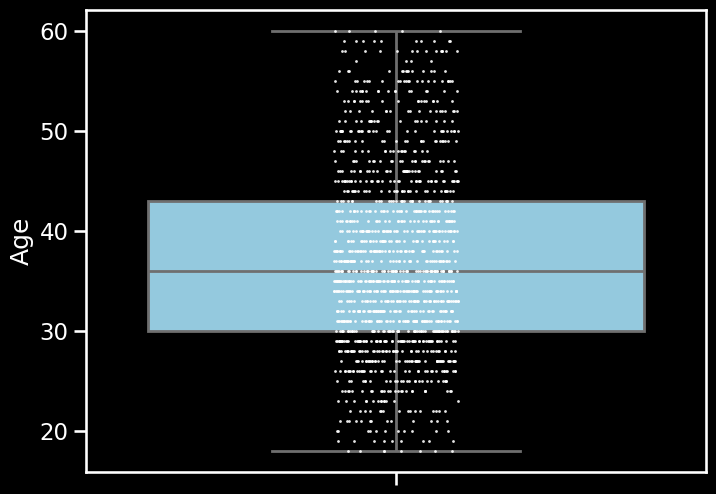

In [9]:
# step0: First do this for 1 columns

fig, ax = plt.subplots(figsize=(8, 6))
col = 'Age'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)

plt.show()

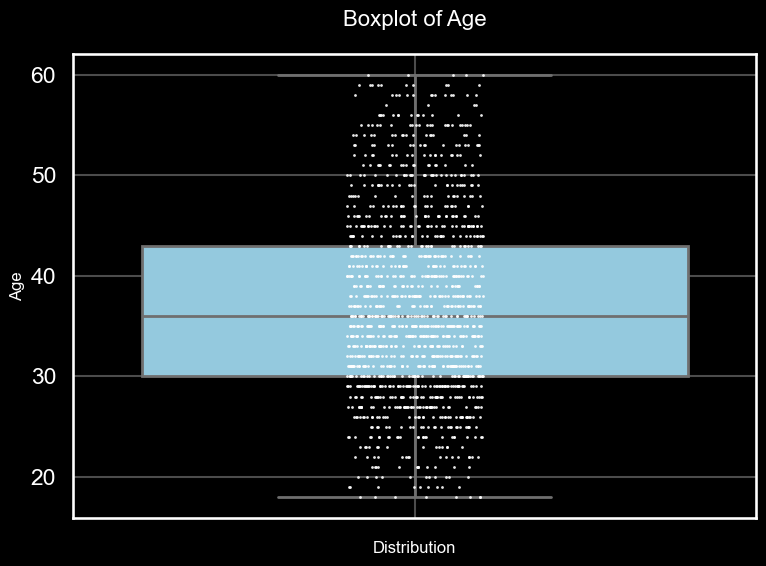

Q1 (25th percentile): 30.0
Q2 (Median, 50th percentile): 36.0
Q3 (75th percentile): 43.0
IQR (Q3 - Q1): 13.0
Outliers:
Series([], Name: Age, dtype: int8)


In [10]:
# step1: Prettify.First do this for 1 columns

sns.set_style("dark")

fig, ax = plt.subplots(figsize=(8, 6))
col = 'Age'

sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)

fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
ax.set_ylabel(col, fontsize=12, color='white')
ax.set_xlabel('Distribution', fontsize=12, color='white')
ax.grid(True, alpha=0.3, color='white')

# Make tick labels visible
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='x', colors='white')

plt.tight_layout()
plt.show()

################################################

# Calculate Q1, Q2, Q3, IQR
Q1 = df[col].quantile(0.25)
Q2 = df[col].quantile(0.5)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median, 50th percentile): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1): {IQR}")

# Identify Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

print(f"Outliers:\n{outliers}")

# Observ: No outliers for Age column
# 50% of employees have age range from Q1=30 to Q3=43 
# You will find outliers in Income, YearsAtCompany. This is to  be expected

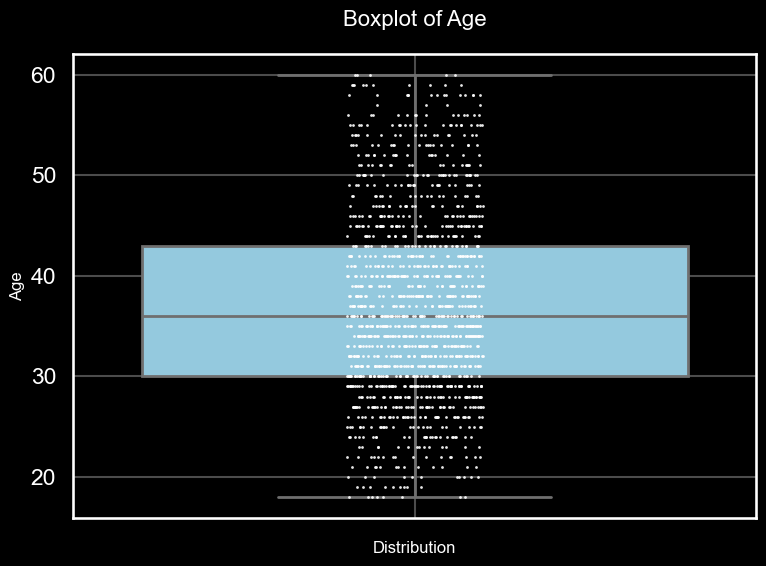

Q1 (25th percentile): 30.0
Q2 (Median, 50th percentile): 36.0
Q3 (75th percentile): 43.0
IQR (Q3 - Q1): 13.0
Outliers:
Series([], Name: Age, dtype: int8)
+++++++++++++++++++++++++++++++




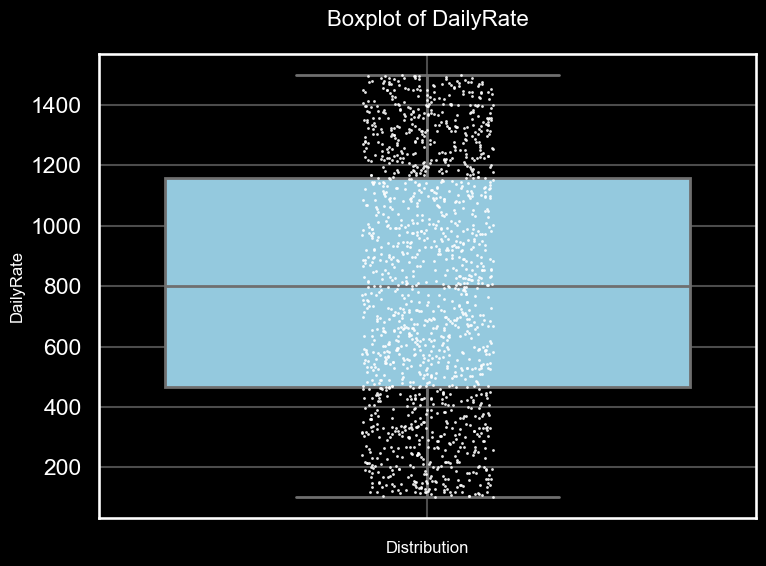

Q1 (25th percentile): 465.0
Q2 (Median, 50th percentile): 802.0
Q3 (75th percentile): 1157.0
IQR (Q3 - Q1): 692.0
Outliers:
Series([], Name: DailyRate, dtype: int16)
+++++++++++++++++++++++++++++++




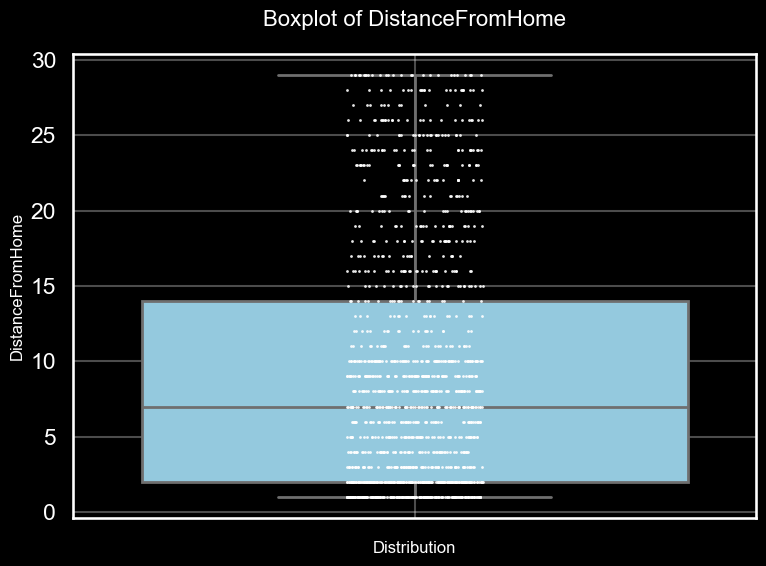

Q1 (25th percentile): 2.0
Q2 (Median, 50th percentile): 7.0
Q3 (75th percentile): 14.0
IQR (Q3 - Q1): 12.0
Outliers:
Series([], Name: DistanceFromHome, dtype: int8)
+++++++++++++++++++++++++++++++




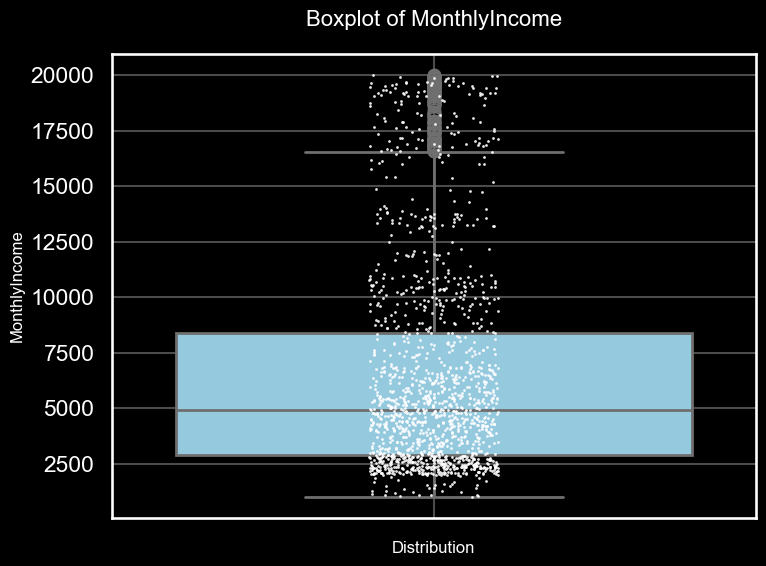

Q1 (25th percentile): 2911.0
Q2 (Median, 50th percentile): 4919.0
Q3 (75th percentile): 8379.0
IQR (Q3 - Q1): 5468.0
Outliers:
25      19094
29      18947
45      19545
62      18740
105     18844
        ...  
1374    17875
1377    19161
1401    19636
1437    19431
1443    18880
Name: MonthlyIncome, Length: 114, dtype: int16
+++++++++++++++++++++++++++++++




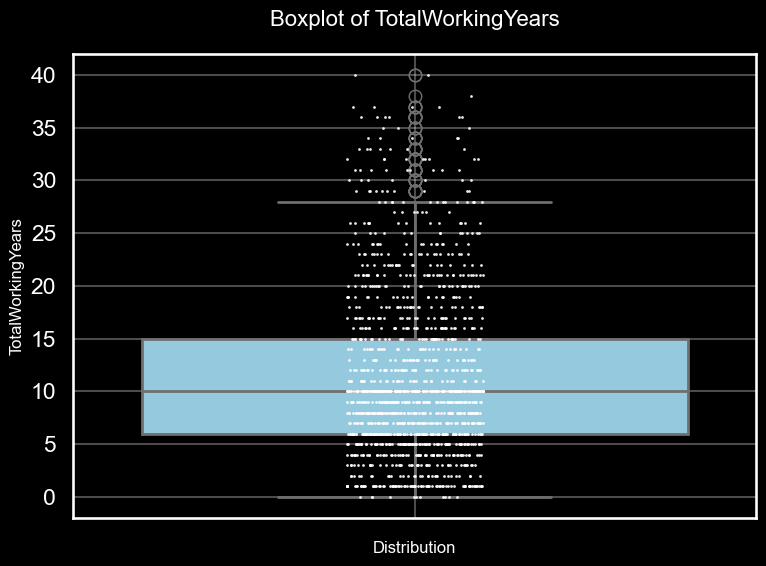

Q1 (25th percentile): 6.0
Q2 (Median, 50th percentile): 10.0
Q3 (75th percentile): 15.0
IQR (Q3 - Q1): 9.0
Outliers:
18      31
62      29
85      37
98      38
105     30
        ..
1264    34
1301    37
1331    29
1374    29
1401    35
Name: TotalWorkingYears, Length: 63, dtype: int8
+++++++++++++++++++++++++++++++




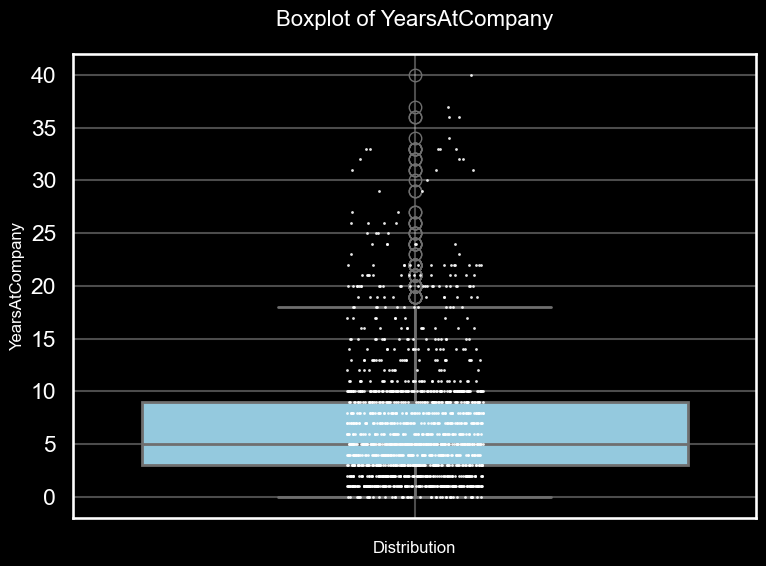

Q1 (25th percentile): 3.0
Q2 (Median, 50th percentile): 5.0
Q3 (75th percentile): 9.0
IQR (Q3 - Q1): 6.0
Outliers:
18      25
28      22
45      22
62      27
63      21
        ..
1403    20
1404    20
1443    22
1445    20
1462    20
Name: YearsAtCompany, Length: 104, dtype: int8
+++++++++++++++++++++++++++++++




In [11]:
# step2: do this for all columns

columns = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome',
           'TotalWorkingYears','YearsAtCompany'
]

for col in columns:

    sns.set_style("dark")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.boxplot(data=df, y=col, color='skyblue', linewidth=2, ax=ax)
    sns.stripplot(data=df, y=col, color='white', size=2, ax=ax, alpha=0.9)
    
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')
    
    ax.set_title(f'Boxplot of {col}', fontsize=16, color='white', pad=20)
    ax.set_ylabel(col, fontsize=12, color='white')
    ax.set_xlabel('Distribution', fontsize=12, color='white')
    ax.grid(True, alpha=0.3, color='white')
    
    # Make tick labels visible
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='x', colors='white')
    
    plt.tight_layout()
    plt.show()

    # Calculate Q1, Q2, Q3, IQR
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.5)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    print(f"Q1 (25th percentile): {Q1}")
    print(f"Q2 (Median, 50th percentile): {Q2}")
    print(f"Q3 (75th percentile): {Q3}")
    print(f"IQR (Q3 - Q1): {IQR}")
    
    # Identify Outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"Outliers:\n{outliers}")
    print("+++++++++++++++++++++++++++++++\n\n")


# KDE

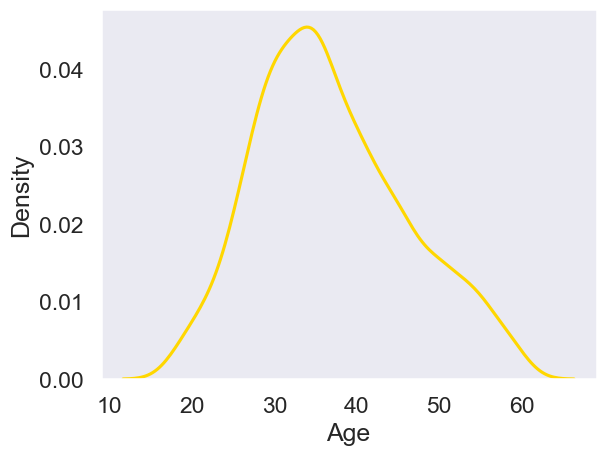

In [13]:
# step0: The basic simple KDE of Age
col = 'Age'

sns.kdeplot(data=df, x=col)
plt.show()

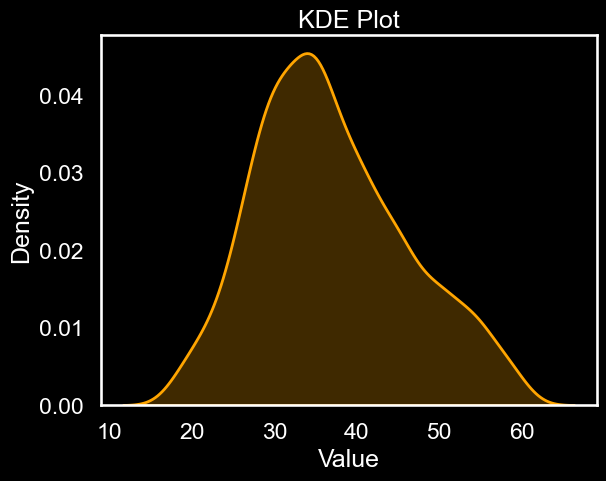

In [14]:
# step1: Now do KDE plot for column Age
plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

col = 'Age'

sns.kdeplot(data=df, x=col, fill=True, color='orange', linewidth=2)

plt.title('KDE Plot')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()

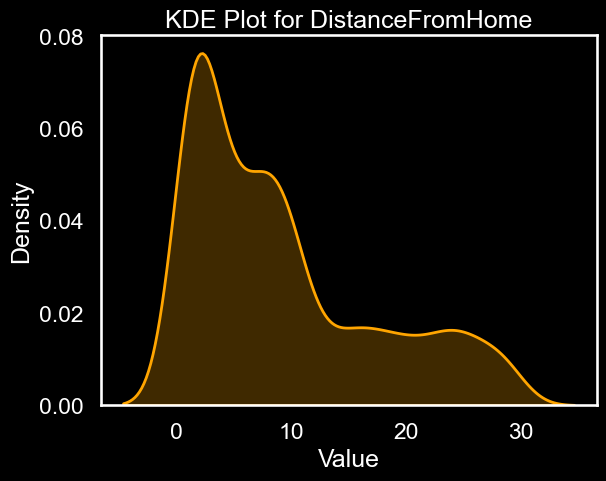

++++++++++++++++++++++



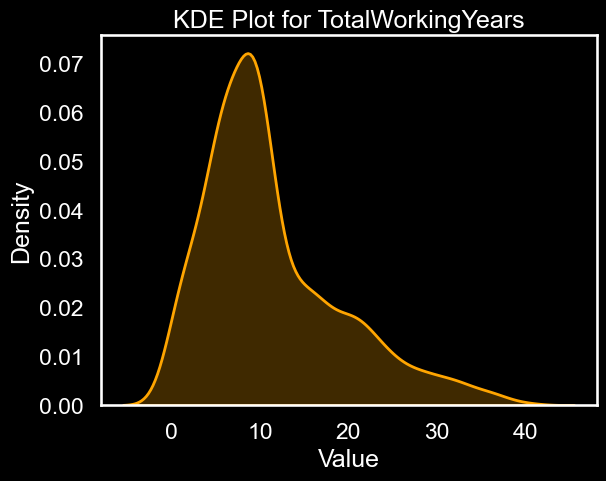

++++++++++++++++++++++



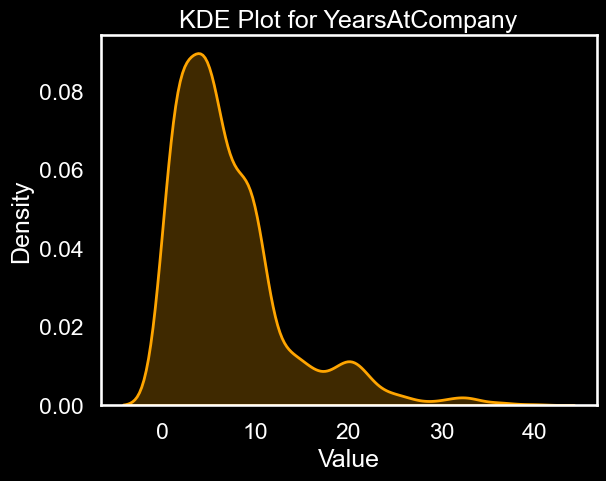

++++++++++++++++++++++



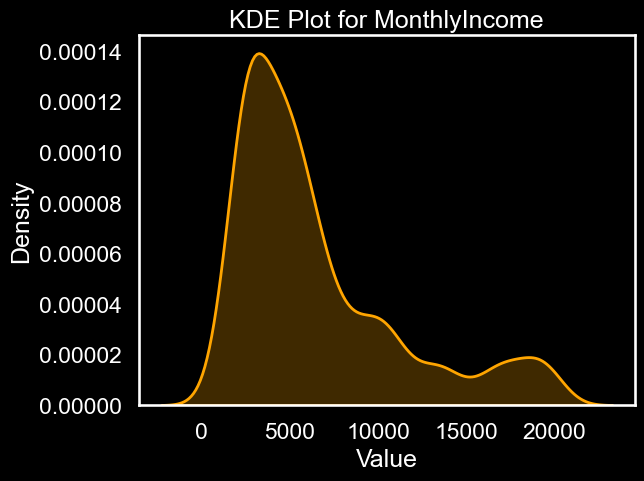

++++++++++++++++++++++



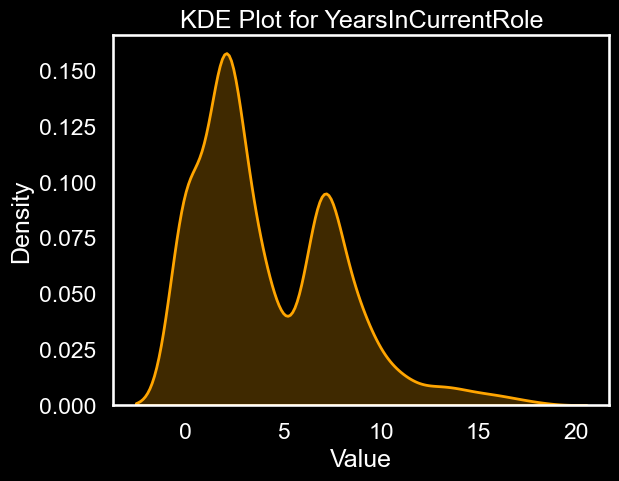

++++++++++++++++++++++



In [10]:
# step2: Now do KDE plot for all numeric columns
# Assuming df is your DataFrame and 'col' is the column of interest

plt.style.use("dark_background")  

# Optional: control Seaborn palette and font scale
sns.set_palette(["gold"])
sns.set_context("talk")

columns = ["DistanceFromHome", "TotalWorkingYears", "YearsAtCompany", "MonthlyIncome", "YearsInCurrentRole"]
for col in columns:
    sns.kdeplot(data=df, x=col, fill=True, color='orange', linewidth=2)
    plt.title(f'KDE Plot for {col}')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.show()
    print("++++++++++++++++++++++\n")


# Observ: DistanceFromHome, TotalworkingYears, YearsAtCompany, Monthly income are Right skewed

## Barplot for categorical columns

In [15]:
# Lets print categorical columns
cat_cols = df.select_dtypes(include='category').columns.tolist()

print(cat_cols)

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


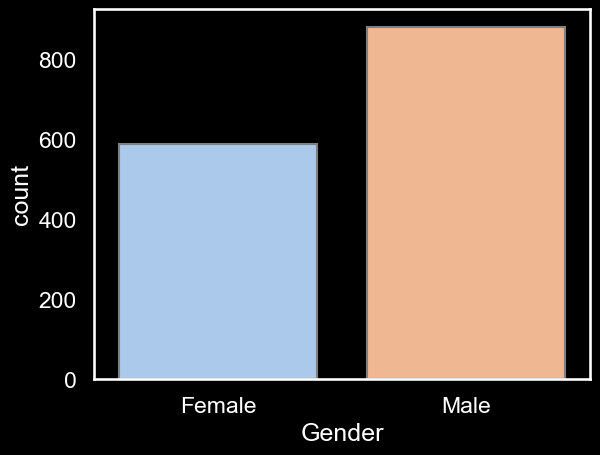

Category counts and percentages for 'Gender':
   Gender  Count  Percentage
0    Male    882        60.0
1  Female    588        40.0

---------------------------------------------



In [16]:
# step0: Do simple barplot for only one column

col = "Gender"

ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.show()
##########################################

# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


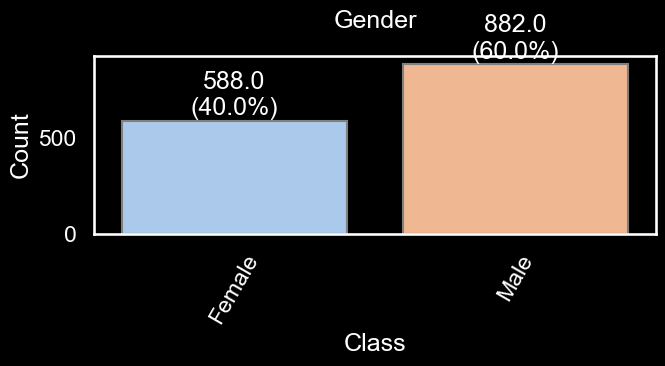

Category counts and percentages for 'Gender':
   Gender  Count  Percentage
0    Male    882        60.0
1  Female    588        40.0

---------------------------------------------



In [17]:
# step1: Prettify above barplot for only one column

col = "Gender"

plt.figure(figsize=(7, 4))
ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.title(f'{col}', pad=20)  # add padding between title and plot
plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks(rotation=60)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
    ax.annotate(f'{height}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2, height + 3),
                ha='center', va='bottom')

plt.tight_layout()  # adjust subplots to give some padding
plt.show()
#####################################


# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


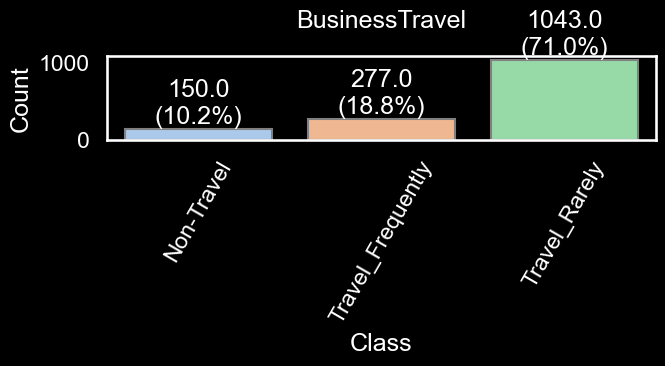

Category counts and percentages for 'BusinessTravel':
      BusinessTravel  Count  Percentage
0      Travel_Rarely   1043   70.952381
1  Travel_Frequently    277   18.843537
2         Non-Travel    150   10.204082

---------------------------------------------



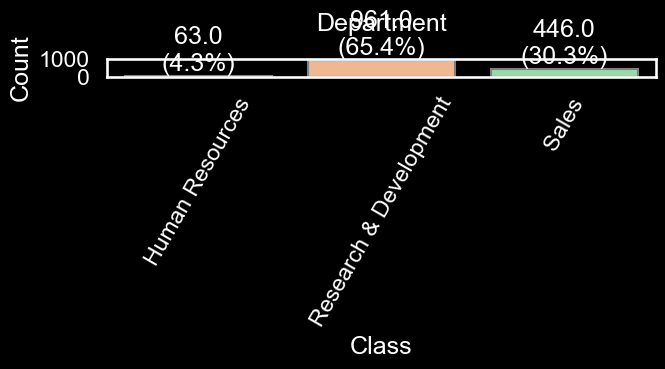

Category counts and percentages for 'Department':
               Department  Count  Percentage
0  Research & Development    961   65.374150
1                   Sales    446   30.340136
2         Human Resources     63    4.285714

---------------------------------------------



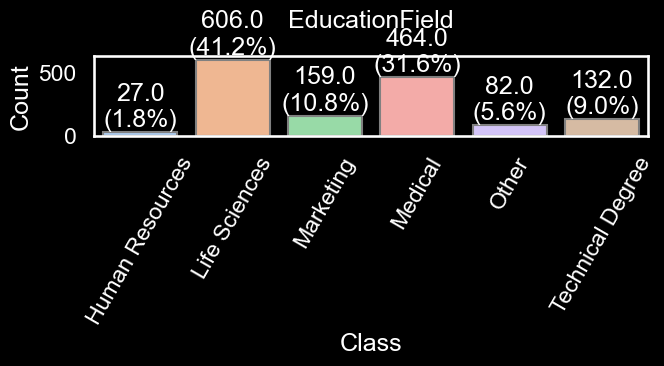

Category counts and percentages for 'EducationField':
     EducationField  Count  Percentage
0     Life Sciences    606   41.224490
1           Medical    464   31.564626
2         Marketing    159   10.816327
3  Technical Degree    132    8.979592
4             Other     82    5.578231
5   Human Resources     27    1.836735

---------------------------------------------



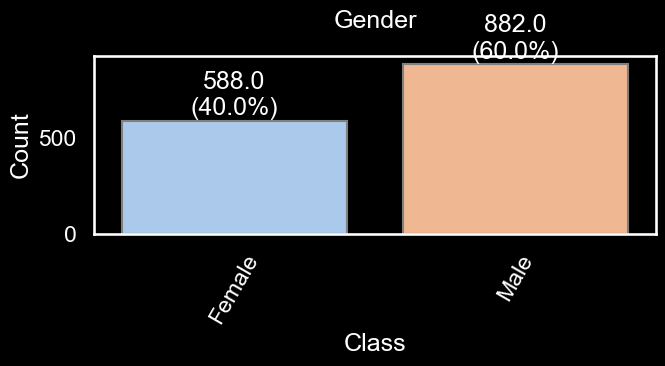

Category counts and percentages for 'Gender':
   Gender  Count  Percentage
0    Male    882        60.0
1  Female    588        40.0

---------------------------------------------



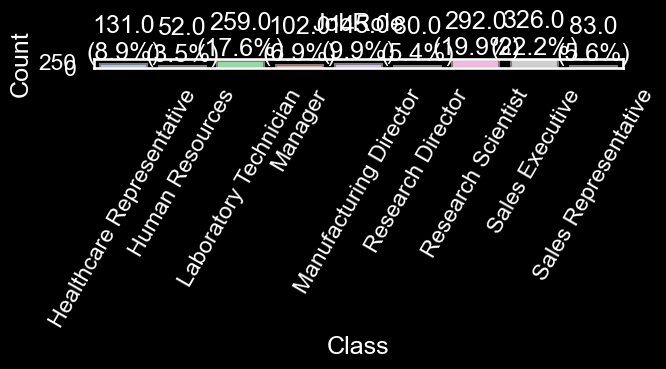

Category counts and percentages for 'JobRole':
                     JobRole  Count  Percentage
0            Sales Executive    326   22.176871
1         Research Scientist    292   19.863946
2      Laboratory Technician    259   17.619048
3     Manufacturing Director    145    9.863946
4  Healthcare Representative    131    8.911565
5                    Manager    102    6.938776
6       Sales Representative     83    5.646259
7          Research Director     80    5.442177
8            Human Resources     52    3.537415

---------------------------------------------



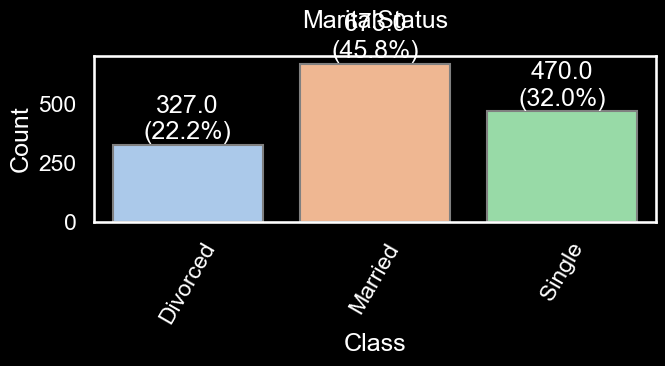

Category counts and percentages for 'MaritalStatus':
  MaritalStatus  Count  Percentage
0       Married    673   45.782313
1        Single    470   31.972789
2      Divorced    327   22.244898

---------------------------------------------



In [ ]:
# step2: Now do this for all columns using for loop

columns = df.select_dtypes(include='category').columns.tolist()

for col in columns:
        
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
    plt.title(f'{col}', pad=20)  # add padding between title and plot
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=60)

    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        percentage = 100 * height / total
        # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
        ax.annotate(f'{height}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2, height + 3),
                    ha='center', va='bottom')
    
    plt.tight_layout()  # adjust subplots to give some padding
    plt.show()

    # Compute the data to print
    count_data = df[col].value_counts().reset_index()
    count_data.columns = [col, 'Count']
    count_data['Percentage'] = 100 * count_data['Count'] / len(df)
    
    # Print the data
    print(f"Category counts and percentages for '{col}':")
    print(count_data)
    print("\n---------------------------------------------\n")


In [14]:
# step3: The above graph looks all jumbled/overlapping: Solution plot each one seperately or work with raw numbers

# Counts of unique values
col = "Gender"
counts = df[col].value_counts()
percentages = df[col].value_counts(normalize=True).mul(100).round(1)

freq_table = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)'])

print(freq_table)

        Count  Percentage (%)
Gender                       
Male      882            60.0
Female    588            40.0


In [ ]:
# step4: Now put above in for loop

columns = df.select_dtypes(include='category').columns.tolist()

for col in  columns:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True).mul(100).round(1)
    
    freq_table = pd.concat([counts, percentages], axis=1, keys=['Count', 'Percentage (%)'])
    
    print(freq_table)
    print("+++++++++\n\n")

# Observ: The column Over18 has all values True. It can be safely dropped

                   Count  Percentage (%)
BusinessTravel                          
Travel_Rarely       1043            71.0
Travel_Frequently    277            18.8
Non-Travel           150            10.2
+++++++++


                        Count  Percentage (%)
Department                                   
Research & Development    961            65.4
Sales                     446            30.3
Human Resources            63             4.3
+++++++++


                  Count  Percentage (%)
EducationField                         
Life Sciences       606            41.2
Medical             464            31.6
Marketing           159            10.8
Technical Degree    132             9.0
Other                82             5.6
Human Resources      27             1.8
+++++++++


        Count  Percentage (%)
Gender                       
Male      882            60.0
Female    588            40.0
+++++++++


                           Count  Percentage (%)
JobRole                     

### Now do Boolean columns

In [19]:
# Lets print Boolean columns
bool_cols = df.select_dtypes(include='boolean').columns.tolist()

print(bool_cols)

['Attrition', 'OverTime']


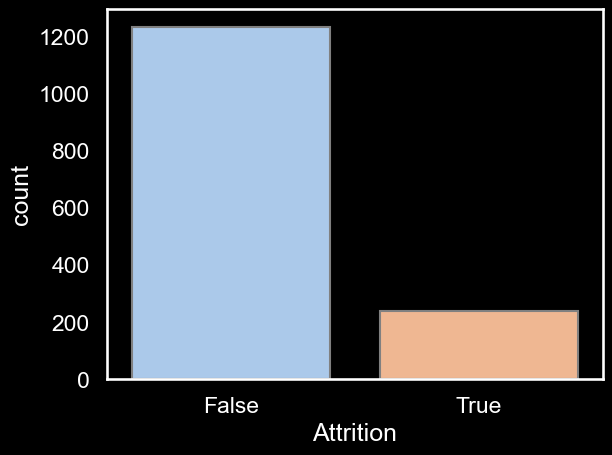

Category counts and percentages for 'Attrition':
   Attrition  Count  Percentage
0      False   1233   83.877551
1       True    237   16.122449

---------------------------------------------



In [20]:
# step0: Do simple barplot for only one column

col = "Attrition"

ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.show()
##########################################

# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


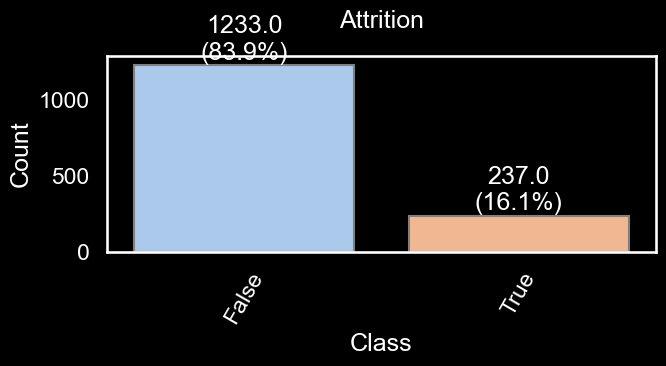

Category counts and percentages for 'Attrition':
   Attrition  Count  Percentage
0      False   1233   83.877551
1       True    237   16.122449

---------------------------------------------



In [22]:
# step1: Prettify above barplot for only one column

col = "Attrition"

plt.figure(figsize=(7, 4))
ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
plt.title(f'{col}', pad=20)  # add padding between title and plot
plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks(rotation=60)

total = len(df)
for p in ax.patches:
    height = p.get_height()
    percentage = 100 * height / total
    # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
    ax.annotate(f'{height}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2, height + 3),
                ha='center', va='bottom')

plt.tight_layout()  # adjust subplots to give some padding
plt.show()
#####################################


# Compute the data to print
count_data = df[col].value_counts().reset_index()
count_data.columns = [col, 'Count']
count_data['Percentage'] = 100 * count_data['Count'] / len(df)

# Print the data
print(f"Category counts and percentages for '{col}':")
print(count_data)
print("\n---------------------------------------------\n")


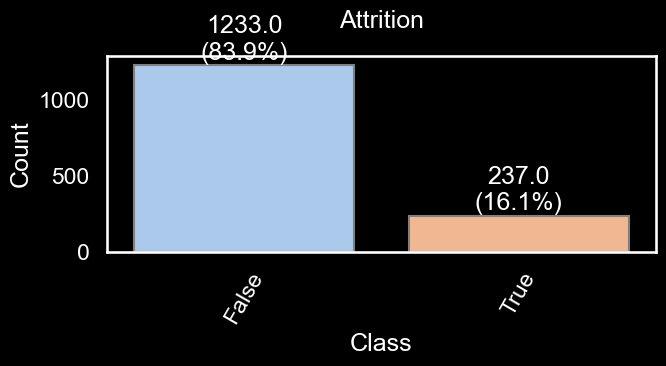

Category counts and percentages for 'Attrition':
   Attrition  Count  Percentage
0      False   1233   83.877551
1       True    237   16.122449

---------------------------------------------



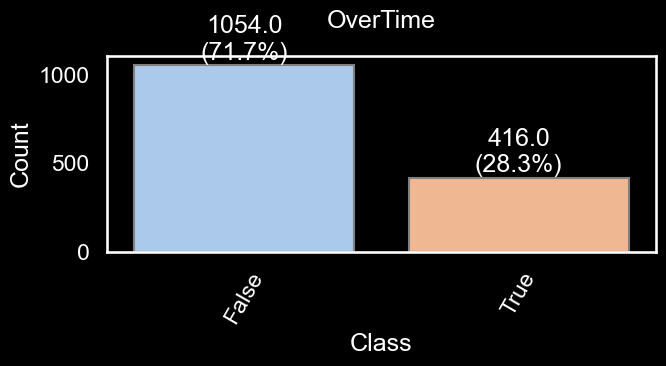

Category counts and percentages for 'OverTime':
   OverTime  Count  Percentage
0     False   1054    71.70068
1      True    416    28.29932

---------------------------------------------



In [23]:
# step2: Now do this for all columns using for loop

bool_cols = df.select_dtypes(include='boolean').columns.tolist()
for col in bool_cols:
        
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(x=col, hue=col, data=df, palette='pastel', edgecolor='gray', legend=False)
    plt.title(f'{col}', pad=20)  # add padding between title and plot
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=60)

    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        percentage = 100 * height / total
        # Add vertical offset (e.g. +3) to y-coordinate to avoid overlap with bar top
        ax.annotate(f'{height}\n({percentage:.1f}%)',
                    (p.get_x() + p.get_width() / 2, height + 3),
                    ha='center', va='bottom')
    
    plt.tight_layout()  # adjust subplots to give some padding
    plt.show()

    # Compute the data to print
    count_data = df[col].value_counts().reset_index()
    count_data.columns = [col, 'Count']
    count_data['Percentage'] = 100 * count_data['Count'] / len(df)
    
    # Print the data
    print(f"Category counts and percentages for '{col}':")
    print(count_data)
    print("\n---------------------------------------------\n")
